In [1]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn scipy requests


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\abdur\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import requests

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [29]:
import requests
import pandas as pd

# Fetch VCT Masters and Champions 2025 events
url = "https://vlrggapi.vercel.app/match/results?page=1"
response = requests.get(url)
print(response.status_code)
print(response.json())

402


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [30]:
url = "https://vlrggapi.vercel.app/events?q=upcoming"
response = requests.get(url)
print(response.status_code)
print(response.json())

402


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [31]:
url = "https://vlrggapi.vercel.app/events?q=completed"
response = requests.get(url)
print(response.status_code)
import json
data = response.json()
# Show just the titles to find Masters/Champions 2025
for event in data['data']['segments']:
    print(event['title'], '-', event['dates'])

402


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
url = "https://vlrggapi.vercel.app/events?q=completed&page=2"
response = requests.get(url)
data = response.json()
for event in data['data']['segments']:
    print(event['title'], '-', event['dates'])

In [5]:
url = "https://vlrggapi.vercel.app/events?q=completed&page=3"
response = requests.get(url)
data = response.json()
for event in data['data']['segments']:
    print(event['title'], '-', event['dates'])

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
url = "https://vlrggapi.vercel.app/events?q=completed&page=4"
response = requests.get(url)
data = response.json()
for event in data['data']['segments']:
    print(event['title'], '-', event['dates'])

In [ ]:
url = "https://vlrggapi.vercel.app/events?q=completed&page=5"
response = requests.get(url)
data = response.json()
for event in data['data']['segments']:
    print(event['title'], '-', event['dates'])

In [6]:
url = "https://vlrggapi.vercel.app/events?q=completed&page=5"
response = requests.get(url)
data = response.json()
for event in data['data']['segments']:
    if 'Champions' in event['title'] or 'Masters' in event['title']:
        print(event['title'], '-', event['url_path'])

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
for page in [6, 7]:
    url = f"https://vlrggapi.vercel.app/events?q=completed&page={page}"
    response = requests.get(url)
    data = response.json()
    for event in data['data']['segments']:
        if 'Champions' in event['title'] or 'Masters' in event['title']:
            print(event['title'], '-', event['url_path'])

In [7]:
for page in [7, 8, 9]:
    url = f"https://vlrggapi.vercel.app/events?q=completed&page={page}"
    response = requests.get(url)
    data = response.json()
    for event in data['data']['segments']:
        if 'Masters' in event['title'] and '2025' in event['title']:
            print(event['title'], '-', event['url_path'])

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
for page in [9, 10, 11]:
    url = f"https://vlrggapi.vercel.app/events?q=completed&page={page}"
    response = requests.get(url)
    data = response.json()
    for event in data['data']['segments']:
        if 'Masters' in event['title'] and '2025' in event['title']:
            print(event['title'], '-', event['url_path'])
            

In [ ]:
url = "https://vlrggapi.vercel.app/match/results?event_id=2283"
response = requests.get(url)
print(response.status_code)
print(response.json())

In [ ]:
# Try different match endpoints
endpoints = [
    "https://vlrggapi.vercel.app/match?q=completed",
    "https://vlrggapi.vercel.app/matches?event_id=2283",
    "https://vlrggapi.vercel.app/stats?event_id=2283",
]

for ep in endpoints:
    r = requests.get(ep)
    print(ep, '-', r.status_code)

In [ ]:
url = "https://vlrggapi.vercel.app/match?q=completed"
response = requests.get(url)
data = response.json()
print(data.keys())
# Show first match
print(data['data']['segments'][0])

In [ ]:
url = "https://vlrggapi.vercel.app/match?q=completed"
response = requests.get(url)
data = response.json()
print(data)

In [ ]:
# Try fetching VLR.gg stats page directly
url = "https://www.vlr.gg/event/stats/2283/valorant-champions-2025"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
print(response.status_code)
print(response.text[:2000])

In [ ]:
import sys
!{sys.executable} -m pip install beautifulsoup4

In [ ]:
from bs4 import BeautifulSoup

url = "https://www.vlr.gg/event/stats/2283/valorant-champions-2025"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

table = soup.find('table')
rows = table.find_all('tr')

data = []
for row in rows:
    cols = [col.get_text(strip=True) for col in row.find_all(['td', 'th'])]
    if cols:
        data.append(cols)

df = pd.DataFrame(data[1:], columns=data[0])
print(df.shape)
print(df.head())

In [ ]:
events = {
    'Masters Bangkok 2025': 'https://www.vlr.gg/event/stats/2281/valorant-masters-bangkok-2025',
    'Masters Toronto 2025': 'https://www.vlr.gg/event/stats/2282/valorant-masters-toronto-2025',
    'Champions 2025': 'https://www.vlr.gg/event/stats/2283/valorant-champions-2025'
}

headers = {'User-Agent': 'Mozilla/5.0'}
all_dfs = []

for event_name, url in events.items():
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table')
    rows = table.find_all('tr')
    data = []
    for row in rows:
        cols = [col.get_text(strip=True) for col in row.find_all(['td', 'th'])]
        if cols:
            data.append(cols)
    df = pd.DataFrame(data[1:], columns=data[0])
    df['Event'] = event_name
    all_dfs.append(df)
    print(f"{event_name}: {df.shape[0]} players")

combined_df = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal: {combined_df.shape[0]} rows, {combined_df.shape[1]} columns")
print(combined_df.head())

In [ ]:
combined_df.to_csv('vct_2025_stats.csv', index=False)
print("Saved to vct_2025_stats.csv")

In [ ]:
print(combined_df['Player'].unique())
print(combined_df.columns.tolist())

In [ ]:
print(combined_df.columns.tolist())

In [ ]:
# Check the raw HTML for team info in the stats table
url = "https://www.vlr.gg/event/stats/2283/valorant-champions-2025"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')
table = soup.find('table')
# Print first 3 rows raw HTML to see what's in there
rows = table.find_all('tr')
for row in rows[1:4]:
    print(row)
    print('---')

In [ ]:
def scrape_event(url, event_name):
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table')
    rows = table.find_all('tr')[1:]  # skip header
    
    data = []
    for row in rows:
        cols = row.find_all(['td', 'th'])
        if not cols:
            continue
        
        # Get player name
        player = row.find('div', class_='text-of')
        player_name = player.get_text(strip=True) if player else ''
        
        # Get team name
        team_div = row.find('div', class_='stats-player-country')
        team = team_div.get_text(strip=True) if team_div else ''
        
        # Get all stat values
        stat_cols = [col.get_text(strip=True) for col in cols]
        
        row_data = [player_name, team] + stat_cols[1:]  # skip first col, add player+team
        data.append(row_data)
    
    # Get headers
    header_row = table.find('tr')
    headers_list = ['Player', 'Team'] + [col.get_text(strip=True) for col in header_row.find_all(['td','th'])][1:]
    
    df = pd.DataFrame(data, columns=headers_list)
    df['Event'] = event_name
    return df

events = {
    'Masters Bangkok 2025': 'https://www.vlr.gg/event/stats/2281/valorant-masters-bangkok-2025',
    'Masters Toronto 2025': 'https://www.vlr.gg/event/stats/2282/valorant-masters-toronto-2025',
    'Champions 2025': 'https://www.vlr.gg/event/stats/2283/valorant-champions-2025'
}

all_dfs = []
for event_name, url in events.items():
    df = scrape_event(url, event_name)
    all_dfs.append(df)
    print(f"{event_name}: {df.shape[0]} players")

combined_df = pd.concat(all_dfs, ignore_index=True)
print(combined_df[['Player', 'Team', 'Event']].head(10))

In [8]:
team_region = {
    # Americas
    'MIBR': 'Americas', 'NRG': 'Americas', 'SEN': 'Americas', 'C9': 'Americas',
    'EG': 'Americas', 'LOUD': 'Americas', 'LEV': 'Americas', '100T': 'Americas',
    'G2': 'Americas', '2G': 'Americas', 'KRU': 'Americas',
    # EMEA
    'TL': 'EMEA', 'TH': 'EMEA', 'FNC': 'EMEA', 'VIT': 'EMEA', 'NAVI': 'EMEA',
    'BBL': 'EMEA', 'GX': 'EMEA', 'KC': 'EMEA', 'M8': 'EMEA', 'FUT': 'EMEA',
    # Pacific
    'T1': 'Pacific', 'DRX': 'Pacific', 'PRX': 'Pacific', 'TLN': 'Pacific',
    'TS': 'Pacific', 'GEN': 'Pacific', 'RRQ': 'Pacific', 'ZETA': 'Pacific',
    'BME': 'Pacific', 'NFB': 'Pacific',
    # CN
    'EDG': 'CN', 'TEC': 'CN', 'FPX': 'CN', 'TYLOO': 'CN', 'NIP': 'CN',
    'TE': 'CN', 'AG': 'CN', 'WOL': 'CN',
}

combined_df['Region'] = combined_df['Team'].map(team_region)
print(combined_df['Region'].value_counts())
print(f"\nUnmapped teams: {combined_df[combined_df['Region'].isna()]['Team'].unique()}")


NameError: name 'combined_df' is not defined

In [9]:
# Fix unmapped teams
extra_mappings = {
    'BLG': 'CN',
    'XLG': 'CN', 
    'DRG': 'Pacific',
}

combined_df['Region'] = combined_df['Region'].fillna(combined_df['Team'].map(extra_mappings))

# Check remaining unmapped
print(combined_df[combined_df['Region'].isna()][['Player', 'Team']])
print(combined_df['Region'].value_counts())

NameError: name 'combined_df' is not defined

In [10]:
# Drop non-VCT rows (tarik's content creator team)
combined_df = combined_df[~combined_df['Team'].isin(['tarik', 'Team'])]

print(combined_df['Region'].value_counts())
print(f"Total players remaining: {len(combined_df)}")

NameError: name 'combined_df' is not defined

In [11]:
combined_df.to_csv('vct_2025_clean.csv', index=False)
print("Saved to vct_2025_clean.csv")
print(combined_df[['Player', 'Team', 'Region', 'ACS', 'ADR', 'KAST', 'Event']].head(10))


NameError: name 'combined_df' is not defined

In [12]:
# Convert numeric columns
numeric_cols = ['Rnd', 'R2.0', 'ACS', 'K:D', 'ADR', 'KPR', 'APR', 'FKPR', 'FDPR', 'K', 'D', 'A', 'FK', 'FD']

# Remove % from KAST and convert
combined_df['KAST'] = combined_df['KAST'].str.replace('%', '').astype(float)

# Remove % from HS%
combined_df['HS%'] = combined_df['HS%'].str.replace('%', '').astype(float)

for col in numeric_cols:
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

print(combined_df.dtypes)
print(f"\nMissing values:\n{combined_df.isnull().sum()}")

NameError: name 'combined_df' is not defined

In [13]:
combined_df.to_csv('vct_2025_clean.csv', index=False)
print("Clean data saved successfully")

NameError: name 'combined_df' is not defined

In [14]:
# Scrape map stats for each event
map_urls = {
    'Masters Bangkok 2025': 'https://www.vlr.gg/event/matches/2281/valorant-masters-bangkok-2025/?series_id=all',
    'Masters Toronto 2025': 'https://www.vlr.gg/event/matches/2282/valorant-masters-toronto-2025/?series_id=all',
    'Champions 2025': 'https://www.vlr.gg/event/matches/2283/valorant-champions-2025/?series_id=all'
}

headers = {'User-Agent': 'Mozilla/5.0'}

for event_name, url in map_urls.items():
    response = requests.get(url, headers=headers)
    print(f"{event_name}: {response.status_code}")
    print(response.text[:500])
    print('---')

Masters Bangkok 2025: 200
<!DOCTYPE html>
<html lang="en" data-theme="light">
	<head>
		<title>
			Valorant Masters Bangkok 2025: Schedule and Results | Valorant Event | VLR.gg		</title>

					<meta name="description" content="Valorant Masters Bangkok 2025 results, upcoming matches, and VODs">
				<meta charset="utf-8">

		<meta property="og:title" content="Valorant Masters Bangkok 2025: Schedule and Results | Valorant Event | VLR.gg">
		<meta property="og:site_name" content="VLR.gg">

					<meta property="og:description
---
Masters Toronto 2025: 200
<!DOCTYPE html>
<html lang="en" data-theme="light">
	<head>
		<title>
			Valorant Masters Toronto 2025: Schedule and Results | Valorant Event | VLR.gg		</title>

					<meta name="description" content="Valorant Masters Toronto 2025 results, upcoming matches, and VODs">
				<meta charset="utf-8">

		<meta property="og:title" content="Valorant Masters Toronto 2025: Schedule and Results | Valorant Event | VLR.gg">
		<meta property="og:site_nam

In [15]:
map_stats_urls = {
    'Masters Bangkok 2025': 'https://www.vlr.gg/event/stats/2281/valorant-masters-bangkok-2025?type=maps',
    'Masters Toronto 2025': 'https://www.vlr.gg/event/stats/2282/valorant-masters-toronto-2025?type=maps',
    'Champions 2025': 'https://www.vlr.gg/event/stats/2283/valorant-champions-2025?type=maps'
}

headers = {'User-Agent': 'Mozilla/5.0'}
all_map_dfs = []

for event_name, url in map_stats_urls.items():
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table')
    if table:
        rows = table.find_all('tr')
        data = []
        for row in rows:
            cols = [col.get_text(strip=True) for col in row.find_all(['td', 'th'])]
            if cols:
                data.append(cols)
        df = pd.DataFrame(data[1:], columns=data[0])
        df['Event'] = event_name
        all_map_dfs.append(df)
        print(f"{event_name}: {df.shape[0]} rows")
        print(df.head(3))
    else:
        print(f"{event_name}: no table found")

NameError: name 'BeautifulSoup' is not defined

In [16]:
url = "https://www.vlr.gg/event/2283/valorant-champions-2025/maps"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')
print(response.status_code)
# Find all tables
tables = soup.find_all('table')
print(f"Found {len(tables)} tables")
for i, t in enumerate(tables):
    print(f"\nTable {i}:")
    print(t.get_text(strip=True)[:300])

NameError: name 'BeautifulSoup' is not defined

In [17]:
# Try the event maps overview page
url = "https://www.vlr.gg/event/2283/valorant-champions-2025"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Look for map related divs
map_divs = soup.find_all('div', class_=lambda c: c and 'map' in c.lower())
print(f"Found {len(map_divs)} map divs")
for d in map_divs[:5]:
    print(d.get_text(strip=True)[:200])
    print('---')

NameError: name 'BeautifulSoup' is not defined

In [18]:
# Regional averages for key metrics
regional_stats = combined_df.groupby('Region')[['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']].mean().round(2)
print(regional_stats)

NameError: name 'combined_df' is not defined

In [19]:
from scipy import stats

regions = ['Americas', 'EMEA', 'Pacific', 'CN']
metrics = ['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'HS%']

print("Kruskal-Wallis Test Results (p < 0.05 = significant difference between regions):\n")
for metric in metrics:
    groups = [combined_df[combined_df['Region'] == r][metric].dropna() for r in regions]
    stat, p = stats.kruskal(*groups)
    sig = '*** SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f"{metric}: H={stat:.3f}, p={p:.4f} — {sig}")

Kruskal-Wallis Test Results (p < 0.05 = significant difference between regions):



NameError: name 'combined_df' is not defined

In [20]:
from itertools import combinations

metrics_significant = ['KAST', 'HS%']
regions = ['Americas', 'EMEA', 'Pacific', 'CN']

print("Mann-Whitney U Post-Hoc Tests:\n")
for metric in metrics_significant:
    print(f"--- {metric} ---")
    for r1, r2 in combinations(regions, 2):
        group1 = combined_df[combined_df['Region'] == r1][metric].dropna()
        group2 = combined_df[combined_df['Region'] == r2][metric].dropna()
        stat, p = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        sig = '*** SIGNIFICANT' if p < 0.05 else 'not significant'
        print(f"{r1} vs {r2}: p={p:.4f} — {sig}")
    print()

Mann-Whitney U Post-Hoc Tests:

--- KAST ---


NameError: name 'combined_df' is not defined

NameError: name 'combined_df' is not defined

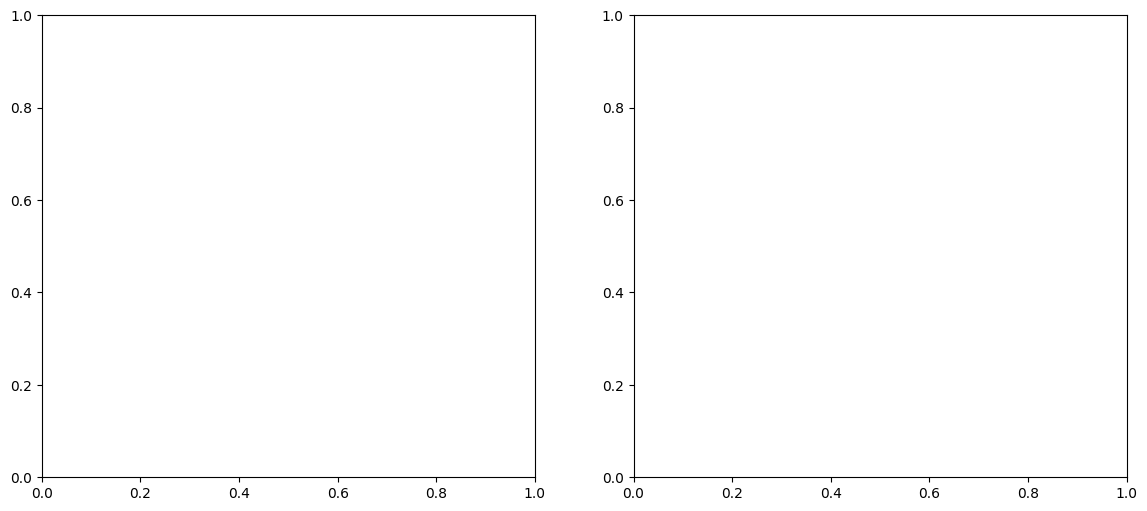

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KAST box plot
sns.boxplot(data=combined_df, x='Region', y='KAST', palette='Set2', ax=axes[0])
axes[0].set_title('KAST% by Region', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('KAST%')

# HS% box plot
sns.boxplot(data=combined_df, x='Region', y='HS%', palette='Set2', ax=axes[1])
axes[1].set_title('Headshot% by Region', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('HS%')

plt.tight_layout()
plt.savefig('kast_hs_boxplots.png', dpi=150)
plt.show()
print("Saved!")

NameError: name 'combined_df' is not defined

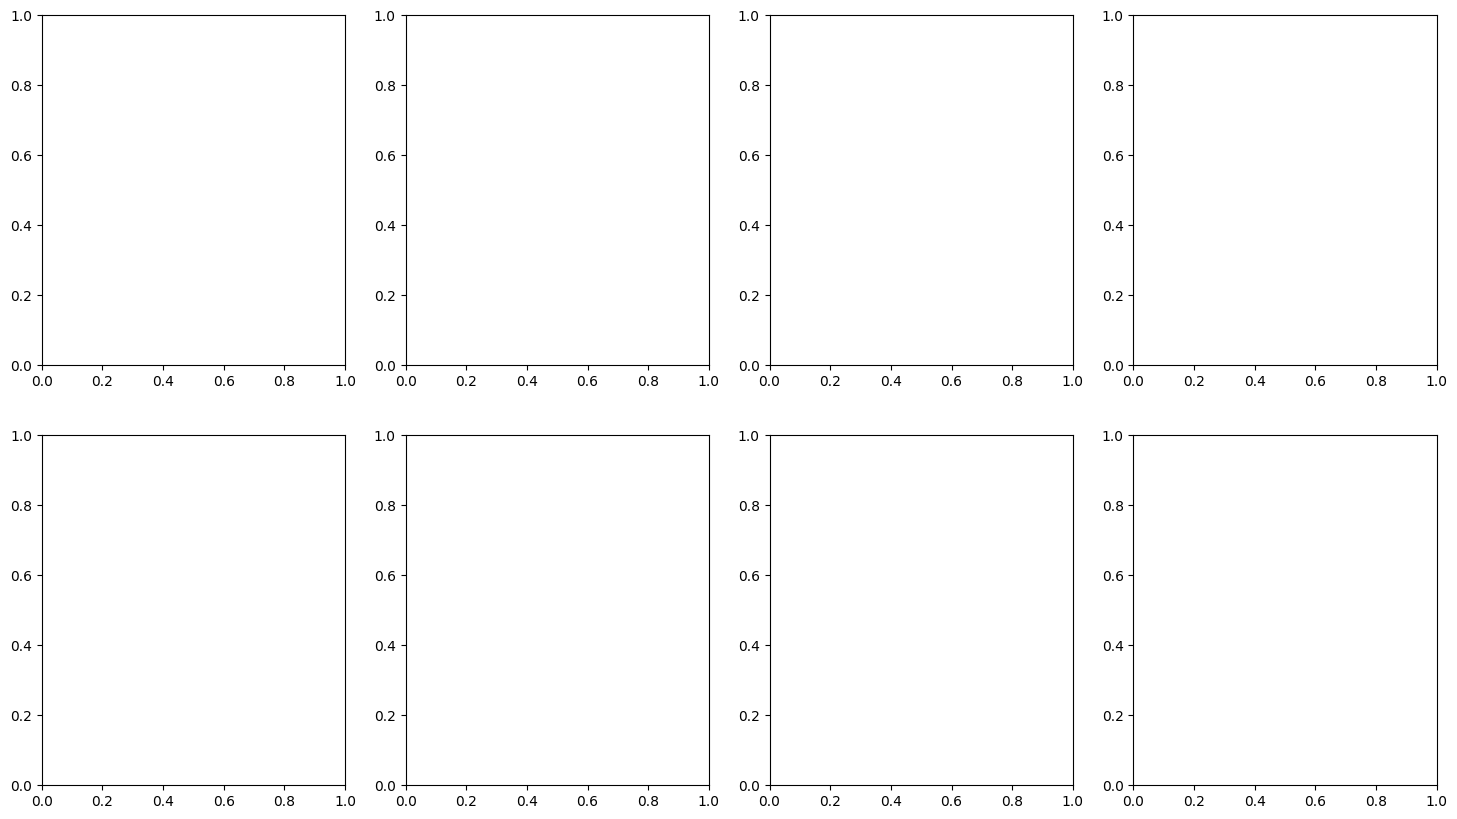

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
metrics = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']

for i, metric in enumerate(metrics):
    ax = axes[i//4][i%4]
    regional_means = combined_df.groupby('Region')[metric].mean()
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
    regional_means.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
    ax.set_title(f'{metric} by Region', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('VCT 2025 Performance Metrics by Region', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('all_metrics_bar.png', dpi=150)
plt.show()
print("Saved!")

NameError: name 'combined_df' is not defined

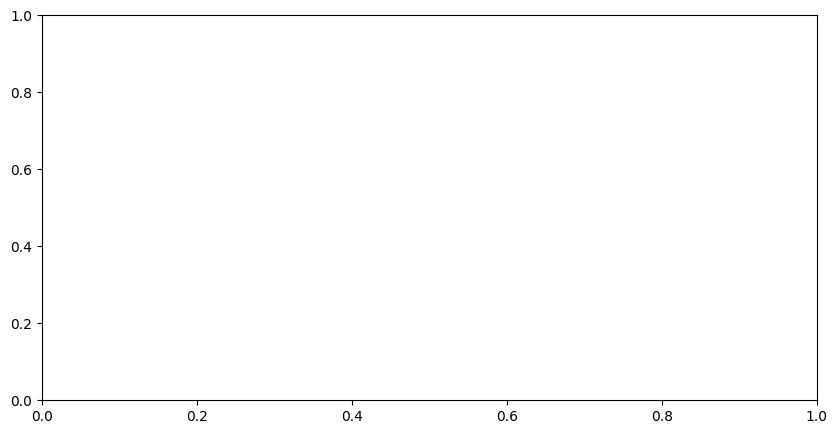

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

# Normalise each metric so they're comparable on same scale
from sklearn.preprocessing import MinMaxScaler

heatmap_data = combined_df.groupby('Region')[['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']].mean()
scaler = MinMaxScaler()
heatmap_normalised = pd.DataFrame(scaler.fit_transform(heatmap_data), 
                                   index=heatmap_data.index, 
                                   columns=heatmap_data.columns)

sns.heatmap(heatmap_normalised, annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=0.5, ax=ax)
ax.set_title('Normalised Regional Performance Heatmap\n(0=lowest, 1=highest)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regional_heatmap.png', dpi=150)
plt.show()
print("Saved!")

In [24]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\abdur\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


NameError: name 'combined_df' is not defined

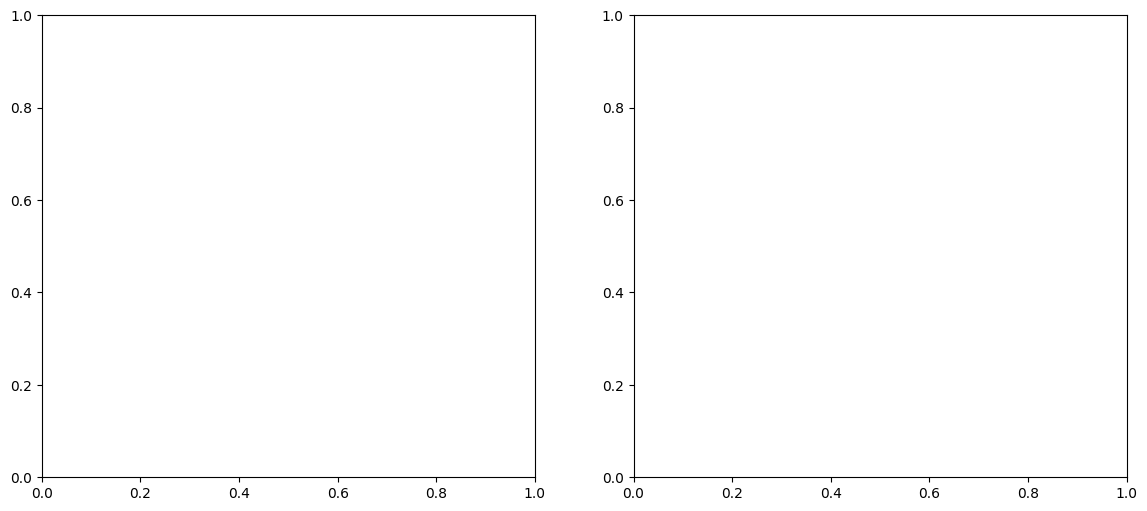

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=combined_df, x='Region', y='KAST', palette='Set2', ax=axes[0], inner='box')
axes[0].set_title('KAST% Distribution by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('KAST%')

sns.violinplot(data=combined_df, x='Region', y='HS%', palette='Set2', ax=axes[1], inner='box')
axes[1].set_title('HS% Distribution by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('HS%')

plt.tight_layout()
plt.savefig('violin_plots.png', dpi=150)
plt.show()
print("Saved!")

In [35]:
events = {
    'Masters Bangkok 2025': 'https://www.vlr.gg/event/stats/2281/valorant-masters-bangkok-2025',
    'Masters Toronto 2025': 'https://www.vlr.gg/event/stats/2282/valorant-masters-toronto-2025',
    'Champions 2025': 'https://www.vlr.gg/event/stats/2283/valorant-champions-2025'
}

headers = {'User-Agent': 'Mozilla/5.0'}
all_rows = []

for event_name, url in events.items():
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table')
    rows = table.find_all('tr')[1:]
    
    for row in rows:
        cols = row.find_all(['td', 'th'])
        if not cols:
            continue
        
        player = cols[0].find('div', style=lambda s: s and 'font-weight: 700' in s)
        team = cols[0].find('div', class_='stats-player-country')
        
        # Extract agent names from image filenames
        agent_imgs = cols[1].find_all('img')
        agent_names = []
        for img in agent_imgs:
            src = img.get('src', '')
            agent_name = src.split('/')[-1].replace('.png', '').replace('.jpg', '')
            if agent_name:
                agent_names.append(agent_name.capitalize())
        agents_str = ', '.join(agent_names)
        
        player_name = player.get_text(strip=True) if player else ''
        team_name = team.get_text(strip=True) if team else ''
        
        stats = [col.get_text(strip=True) for col in cols[2:]]
        all_rows.append([player_name, team_name, agents_str] + stats + [event_name])

# Get column headers
response = requests.get(list(events.values())[0], headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')
header_row = soup.find('table').find('tr')
col_names = ['Player', 'Team', 'Agents'] + [th.get_text(strip=True) for th in header_row.find_all('th')[2:]] + ['Event']

combined_df = pd.DataFrame(all_rows, columns=col_names)
print(combined_df[['Player', 'Team', 'Agents']].head(10))

    Player Team                  Agents
0  CHICHOO  EDG       Viper, Vyse, Omen
1     nAts   TL  Viper, Chamber, Cypher
2    trent   G2              Tejo, Sova
3    Derke  VIT        Raze, Yoru, Jett
4      iZu   T1      Yoru, Fade, Cypher
5  free1ng  DRX                    Tejo
6    keiko   TL       Raze, Astra, Omen
7    trexx  VIT   Brimstone, Fade, Sova
8     BeYN  DRX      Breach, Sova, Fade
9     BuZz   T1        Raze, Neon, Yoru


In [36]:
# Remove non-VCT rows
combined_df = combined_df[~combined_df['Team'].isin(['tarik', 'Team'])]

# Convert numeric columns
numeric_cols = ['Rnd', 'R2.0', 'ACS', 'K:D', 'ADR', 'KPR', 'APR', 'FKPR', 'FDPR', 'K', 'D', 'A', 'FK', 'FD']
combined_df['KAST'] = combined_df['KAST'].str.replace('%', '').astype(float)
combined_df['HS%'] = combined_df['HS%'].str.replace('%', '').astype(float)
for col in numeric_cols:
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

# Region mapping
team_region = {
    'MIBR': 'Americas', 'NRG': 'Americas', 'SEN': 'Americas', 'C9': 'Americas',
    'EG': 'Americas', 'LOUD': 'Americas', 'LEV': 'Americas', '100T': 'Americas',
    'G2': 'Americas', '2G': 'Americas', 'KRU': 'Americas',
    'TL': 'EMEA', 'TH': 'EMEA', 'FNC': 'EMEA', 'VIT': 'EMEA', 'NAVI': 'EMEA',
    'BBL': 'EMEA', 'GX': 'EMEA', 'KC': 'EMEA', 'M8': 'EMEA', 'FUT': 'EMEA',
    'T1': 'Pacific', 'DRX': 'Pacific', 'PRX': 'Pacific', 'TLN': 'Pacific',
    'TS': 'Pacific', 'GEN': 'Pacific', 'RRQ': 'Pacific', 'ZETA': 'Pacific',
    'BME': 'Pacific', 'NFB': 'Pacific', 'DRG': 'Pacific',
    'EDG': 'CN', 'TEC': 'CN', 'FPX': 'CN', 'TYLOO': 'CN', 'NIP': 'CN',
    'TE': 'CN', 'AG': 'CN', 'WOL': 'CN', 'BLG': 'CN', 'XLG': 'CN',
}

combined_df['Region'] = combined_df['Team'].map(team_region)
print(combined_df['Region'].value_counts())
print(f"Total: {len(combined_df)} players")

# Save
combined_df.to_csv('vct_2025_clean.csv', index=False)
print("Saved!")

Region
Pacific     51
EMEA        47
Americas    45
CN          40
Name: count, dtype: int64
Total: 183 players
Saved!
